# PROJET DE TRAITEMENTS DISTRIBUES
Edoardo PICIUCCHI, Aurélien DUVIGNAC-ROSA, Jean-Marc FAUVEL

# Présentation

Le projet consiste en l'étude d'un article intitulé : « CCF : Fast and Scalable Connected Component Computation in MapReduce » (« CCF : Calcul de composantes connexes rapide et scalable en MapReduce »). Cet article a été publié en 2013 par Jimmy Lin et Michael Schatz. Il propose un algorithme de calcul de composantes connexes en utilisant le modèle de programmation MapReduce. Cet algorithme est basé sur l'algorithme de Label Propagation. Il est conçu pour être rapide et scalable, c'est-à-dire qu'il peut être utilisé sur de grands ensembles de données et sur un grand nombre de machines.

L'algorithme a pour objectif d’identifier les sous-graphes connectés au sein d’un graphe G. Le graphe analysé doit être représenté par une collection de paires (N1, N2) où N1 et N2 sont des noeuds du graph G qui ont une connexion entre eux. Le couple (N1, N2) représente une arête du graphe.
L’algorithme présenté dans ce papier va permettre d’identifier des sous-graphes connectés entre eux en modifiant les paires des sous-graphes afin qu’elles soient toutes constituées ainsi : (N, Nmin) où N est un noeud du sous graph et Nmin le noeud de plus petite valeur appartenant au même sous-graphe.
Par ailleurs, l’algorithme ayant pour objet de permettre de traiter des graphes de grande taille, il adopte une programmation distribuée de type MapReduce, permettant ainsi de répartir le traitement sur plusieurs machines et permettre le traitement des données de manière parallèle.

## Objectifs du projet

1. Lire, comprendre et expliquer l’algorithme décrit dans le papier de Hakan Kardes, Siddharth Agrawal, Xin Wang et Ang Sun intitulé « *CCF : Fast and Scalable Connected Component Computation in MapReduce* » ;
2. Coder l’algorithme en Spark en utilisant à la fois des *RDD* (*Resilient Distributed Dataset*) et *DataFrame* ;
3. L’implémentation doit être exécutée en Python, et optionnellement en *Scala* ;
4. Effectuer une analyse comparative des versions en *RDD* et *DataFrame* sur des graphes de tailles croissantes ;
5. Utilisation de *DataBricks* pour les petits graphes, et *Google Cloud Cluster* pour les plus gros (<20 Gb).

## Introduction et description de l'algorithme CCF

Cet algorithme repose sur deux tâches principales : *CCF-Iterate* et *CCF-Dedup* dont l'objectif est d'obtenir les composantes connexes présentes dans le graphe d'entrée.

### Explication des deux principales tâches

**CCF-iterate** : cette tâche a pour objectif de propager les étiquettes des composants. Chaque nœud met à jour son étiquette afin d'extraire l'étiquette la plus petite. Ce processus se poursuit jusqu'à ce que les étiquettes atteignent un état de stabilité.

**CCF-dedup** : Cette tâche traite de la gestion de la suppression des arêtes redondantes afin d'éviter des calculs superflus en réduisant le graphe.

### Présentation de l'algorithme pas à pas

**Données d'entrées** : Les données d'entrées sont des paires de nœuds (N1, N2) qui représentent les arêtes du graphe. Ces paires sont stockées sous forme d'un graphe noté $G = (V, E)$ avec $V$ (*vertices*) les sommets et $E$ (*edges*) les arrêtes.

**Données de sortie** : Les données de sortie sont des paires de nœuds (N, Nmin) où N est un nœud du sous-graphe et Nmin est le nœud de plus petite valeur appartenant au même sous-graphe. Ces paires sont stockées sous forme d'un graphe noté $G' = (V', E')$ avec $V'$ les sommets et $E'$ les arrêtes.





## Implémentation de l'algorithme CCF en paradigme Spark

L'implémentation décrite ci-dessous permet de réaliser les étapes de l'algorithme *CCF* décrites dans l'exemple de l'article.
Les résultats obtenus nous ont permis de constater une erreur au niveau de l'exemple. En effet, dans la figure 5.1 de l'article, le lien entre H et G n'est pas transmis dans le graphe présent dans la colonne *reducer*.

Pour le prouver, il suffit d'instancier le paramètre `debug` à `True` dans la méthode `workflow` décrite ci-dessous. Cela permettra d'afficher les graphes successifs obtenus après chaque itération de l'algorithme.

### Importation des librairies

In [17]:
from abc import ABC, abstractmethod
from pyspark import SparkConf, SparkContext
from pyspark.rdd import RDD, Partitioner
from pyspark.sql import SparkSession
from pyspark.sql.functions import *
from pyspark.sql.types import IntegerType
from scipy.optimize import curve_fit

import builtins
import gzip
import io
import logging
import matplotlib.pyplot as plt
import numpy as np
import pyspark
import requests
import time

### Création de la classe abstraite `Graph`

Pour implémenter l'algorithme *CCF* en *Spark*, nous avons créé une classe abstraite `Graph` qui permet de représenter un graphe. Cette classe est composée de plusieurs méthodes permettant d'appliquer les opérations *map*, *reduce* et d'appliquer l'algorithme *CCF* sur le graphe.
L'objectif de cette classe est double. D'une part, elle permet de définir les méthodes nécessaires à l'implémentation de l'algorithme *CCF*. D'autre part, elle assure une meilleure lisibilité du code puisqu'elle permet de définir les méthodes nécessaires à l'implémentation de deux classes filles, respectivement associées aux structures de type *Resilient Distributed Dataset* et *DataFrame*.
En effet, comme présenté dans le code ci-dessous, la méthode `ccf` est définie dans la classe mère, mais est appelée dans les classes filles :  permettant ainsi de réduire la redondance du code et d'assurer une meilleure lisibilité.

La représentation d'un graphe se fait par l'intermédiaire de la classe abstraite `Graph`. C'est à partir de celle-ci que deux autres classes, respectivement associées aux structures de type *Resilient Distributed Dataset* et *DataFrame*, seront créées.

La classe `Graph` est composée de trois attributs :
- `sparksession` : la session Spark courante ;
- `edges` : une liste d'éléments de type chaîne de caractères représentant les arêtes du graphe ;
- `numSlices` : un entier représentant le nombre de partitions du graphe (si `numSlices` n'est pas instancié, cette valeur est défini par `pyspark`);

Ainsi que de plusieurs méthodes :
- `__init__` : le constructeur de la classe ;
- `parallelize_edges` : Convertir une liste d'arêtes en une RDD distribuée ;
- `__str__` : permet d'afficher le graphe ;
- `format_data` : permet de formater les données du graphe selon que nous utilisions le formation *Resilient Distributed Dataset* (RDD) ou DataFrame (celle-ci est redéfinie dans les classes filles). Remarquons également que cette méthode est instanciée avec le décorateur `@staticmethod` qui permet de l'appeler sans faire appel à une instance de la classe. De plus cette méthode est définie comme une méthode abstraite, c'est-à-dire qu'elle doit être redéfinie dans les classes filles ;
- `fetch` : permet d'afficher les composantes connexes du graphe à l'issue de l'application de l'algorithme CCF;
- `map_ccf_iterate` : permet de mapper les noeuds du graphe en créant un graphe bidirectionnel. Cette méthode est instanciée avec le décorateur `@abstractmethod` qui permet de la redéfinir dans les classes filles ;
- `reduce_ccf_iterate` : permet de réduire le graphe en fusionnant les noeuds connectés. Au même titre que la méthode `mapper`, cette méthode est instanciée avec le décorateur `@abstractmethod` qui permet de la redéfinir dans les classes filles ;
- `ccf_iterate` : permet d'appliquer l'algorithme CCF sur le graphe. Cette méthode est définie directement dans la classe mère sans être redéfinie dans les classes filles. Elle permet d'appeler les méthodes `mapper` et `reducer`, redéfinies dans les classes files, pour chaque itération de l'algorithme CCF ;
- `ccf_dedup` : permet de supprimer les arêtes redondantes du graphe. Cette méthode est définie directement dans la classe mère sans être redéfinie dans les classes filles. Elle permet d'appeler la méthode `ccf_iterate` pour chaque itération de l'algorithme CCF ;
- `get_distinct_clusters_count` : permet de compter le nombre de composantes connexes du graphe. Il s'agit d'une méthode abstraite qui doit être redéfinie dans les classes filles ;
- `get_clusters` : permet de récupérer les composantes connexes du graphe sous forme de dictionnaire. Il s'agit d'une méthode abstraite qui doit être redéfinie dans les classes filles ;
- `workflow` : permet de définir le workflow de l'algorithme CCF. Cette méthode est définie directement dans la classe mère sans être redéfinie dans les classes filles. Elle permet d'appeler la méthode `ccf_iterate` pour chaque itération de l'algorithme CCF et d'afficher le graphe obtenu à chaque itération dans le cas où la valeur `debug` est instanciée à `True`.

**Remarque relatives aux méthodes citées préalablement**

- Les méthodes `ccf_iterate`, `ccf_dedup` et `workflow` sont définies dans la classe mère `Graph` sans être redéfinies dans les classes filles. En effet, ces méthodes appellent les méthodes `map_ccf_iterate`, `reduce_ccf_iterate`, `get_distinct_clusters_count` et `get_clusters` qui sont redéfinies dans les classes filles. Ainsi, les méthodes `ccf_iterate`, `ccf_dedup` et `workflow` sont des méthodes génériques qui permettent d'appliquer l'algorithme CCF sur un graphe sans se soucier de la structure de données utilisée.

- La méthode `ccf_itarate` implémente fidélement l'algorithme CCF décrit dans l'article. Elle est composée de deux boucles imbriquées. La première boucle permet de mapper les noeuds du graphe. La seconde boucle permet de réduire les noeuds connectés.
Cependant étant donné que Pyspark s'exécute de manière *lazy*, c'est-à-dire qu'il ne calcule les transformations que lorsqu'une action est appelée, nous avons ajouté une action `count` à l'issue des transformations `map` et `reduce` pour forcer l'exécution de ces transformations.

In [18]:
class Graph(ABC):

  def __init__(self, spark_session, edges, numSlices=None):
    """
    Initialise la classe Graph avec la session Spark et la liste d'arêtes fournies.

    Paramètres :
        spark_session (SparkSession) : La session Spark actuelle utilisée pour les calculs distribués.
        edges (list) : Une liste d'arêtes, où chaque arête est représentée sous forme de chaîne de caractères.
                       Chaque chaîne correspond généralement à une connexion entre deux nœuds du graphe.
        numSlices (int, optionnel) : Le nombre de partitions à créer pour le RDD du graphe.
                                     Si None, le partitionnement par défaut de Spark sera utilisé.

    Attributs :
        spark_session (SparkSession) : Stocke la session Spark fournie.
        spark_context (SparkContext) : Le contexte Spark extrait de la session Spark.
        graph (RDD ou DataFrame) : Initialisé à None. Représente la structure du graphe
                                   qui sera créée à partir des arêtes en entrée.
        data_type (str) : Un espace réservé pour spécifier le type de données du graphe (par exemple, RDD, DataFrame).
                          Par défaut, la valeur est None et doit être définie dans les sous-classes.
        clusters (dict) : Initialisé à None. Utilisé pour stocker les données des clusters après
                          l'application de l'algorithme des composantes connexes.
        len_input_edges (int) : La longueur de la liste d'arêtes en entrée, représentant
                                le nombre d'arêtes dans le graphe.
        ccf_metrics (dict) : Un dictionnaire pour stocker les métriques de performance et les résultats
                             de l'algorithme des composantes connexes, tels que le temps d'exécution,
                             le nombre d'itérations et les clusters résultants.
    """
    self.spark_session = spark_session
    self.spark_context = self.spark_session.sparkContext
    self.spark_context.setLogLevel("INFO")
    self.graph = None
    self.data_type = None
    self.clusters = None
    self.len_input_edges = len(edges)
    self.ccf_metrics = {}

  @staticmethod
  def parallelize_edges(spark_context, edges, numSlices=None):
    """
    Convertit une liste d'arêtes en un RDD distribué.

    Paramètres :
        spark_context (SparkContext) : Le contexte Spark utilisé pour la parallélisation.
        edges (list) : Une liste d'arêtes, où chaque arête est représentée sous forme de chaîne de caractères.
        numSlices (int, optionnel) : Le nombre de partitions à créer pour le RDD.
                                     Si None, le partitionnement par défaut de Spark sera utilisé.

    Returns :
        RDD : Un RDD distribué contenant les arêtes de la liste en entrée.
    """
    return spark_context.parallelize(edges, numSlices)

  @staticmethod
  def format_data(data):
    pass # méthode abstraite, doit être implémentée par les classes filles

  def __str__(self):
    """
    Retourne une représentation textuelle du graphe.

    Cette méthode utilise la fonction `format_data` pour formater les données
    du graphe afin de les rendre plus lisibles et les renvoie sous forme de chaîne.
    Le formatage réel dépend de l'implémentation de `format_data` dans la sous-classe.

    Returns :
        str : Une représentation textuelle formatée du graphe.
        Exemple :
        A -> B
        B -> C
        B -> D
        D -> E
        F -> G
        G -> H
    """
    return self.format_data(self.graph)

  @staticmethod
  def fetch(data):
    pass # méthode abstraite, doit être implémentée par les classes filles

  @abstractmethod
  def map_ccf_iterate(self):
    pass # méthode abstraite, doit être implémentée par les classes filles

  @abstractmethod
  def reduce_ccf_iterate(self):
    pass # méthode abstraite, doit être implémentée par les classes filles

  def ccf_iterate(self, debug=False):
    """
    Exécute le processus itératif de l'algorithme de recherche des composantes connexes (CCF).

    Cette méthode applique de manière itérative les étapes de mappage et de réduction de
    l'algorithme CCF jusqu'à ce qu'aucune nouvelle paire ne soit générée (c'est-à-dire, convergence).
    Elle utilise les méthodes `map_ccf_iterate` et `reduce_ccf_iterate` pour les opérations
    de mappage et de réduction respectivement, et déduplique les arêtes à chaque itération
    à l'aide de la méthode `ccf_dedup`.

    Paramètres :
        debug (bool) : Si True, active le mode débogage pour afficher des journaux détaillés
                       à chaque itération, y compris les états intermédiaires des données.

    Returns :
        tuple : Un tuple contenant :
            - nb_iteration (int) : Le nombre total d'itérations effectuées.
            - data (RDD ou DataFrame) : Les données du graphe résultantes après application
                                        de l'algorithme CCF.

    Étapes clefs :
        1. Initialiser l'accumulateur pour suivre les nouvelles paires générées à chaque itération.
        2. Effectuer l'étape de mappage à l'aide de `map_ccf_iterate`.
        3. Effectuer l'étape de réduction à l'aide de `reduce_ccf_iterate` et mettre à jour l'accumulateur.
        4. Dédupliquer les arêtes à l'aide de `ccf_dedup` pour réduire la redondance.
        5. Déclencher l'exécution avec `.count()` pour évaluer les transformations en raison de
           l'exécution paresseuse de PySpark.
        6. Répéter les étapes ci-dessus jusqu'à ce qu'aucune nouvelle paire ne soit générée.
        7. Enregistrer les états intermédiaires si `debug` est activé.
    """
    if debug:
      print(f"Execution de ccf_iterate avec {self.data_type} sur {self.len_input_edges} arrêtes d'entrée.")
    nb_iteration = 0
    data = self.graph
    # Initialize accumulator here to be task-specific
    nb_new_pair = -1
    if debug:
      print(f"iteration {nb_iteration} \n{self}")
    while nb_new_pair != 0:
      nb_iteration += 1
      # Effectue les étapes de mapping et de réduction de manière itérative.
      data_map_ccf_iterate = self.map_ccf_iterate(data, debug)
      data_reduce_ccf_iterate, nb_new_pair = self.reduce_ccf_iterate(data_map_ccf_iterate, debug)
      # Supprime les arêtes en double pour réduire la redondance des données
      data_reduce_distinct = self.ccf_dedup(data_reduce_ccf_iterate,debug)
      data = data_reduce_distinct

      # Déclenche l'exécution sans ramener les données
      # Cette commande est due à l'évaluation paresseuse de PySpark
      # count() permet de déclencher l'exécution des transformations sans
      # collecter toutes les données sur le driver (ce qui est plus léger que
      # collect()).
      data_reduce_distinct.count()

      if debug :
        data_str_map_ccf_iterate = self.format_data(data_map_ccf_iterate)
        data_str_reduce_ccf_iterate = self.format_data(data_reduce_ccf_iterate)
        data_str_reduce_distinct = self.format_data(data_reduce_distinct)
        print(f"Iteration {nb_iteration} \nMapper : \n{data_str_map_ccf_iterate} \nReducer : \n{data_str_reduce_ccf_iterate} \nReducer.ccf_dedup() : \n{data_str_reduce_distinct} \nNew pairs : {nb_new_pair}")

    return nb_iteration, data

  @staticmethod
  def ccf_dedup(data, debug=False):
    pass # méthode abstraite, doit être implémentée par les classes filles

  @staticmethod
  def get_distinct_clusters_count(data):
    pass # méthode abstraite, doit être implémentée par les classes filles

  @staticmethod
  def get_clusters(data):
    pass # méthode abstraite, doit être implémentée par les classes filles

  def workflow(self, debug=False):
    """
    Exécute le workflow complet de l'algorithme de recherche des composantes connexes (CCF).

    Cette méthode exécute l'algorithme CCF, mesure son temps d'exécution et collecte
    diverses métriques telles que le nombre d'itérations, les clusters résultants et
    le temps d'exécution. Elle permet également le débogage en affichant les résultats
    intermédiaires et en formatant les résultats finaux.

    Paramètres :
        debug (bool) : Si True, active le mode débogage pour consigner des informations
                       détaillées sur l'exécution du workflow, y compris les résultats
                       intermédiaires et finaux.

    Étapes clés :
        1. Mesurer le temps de début d'exécution.
        2. Exécuter l'algorithme CCF via la méthode `ccf_iterate`.
        3. Mesurer le temps de fin d'exécution et calculer la durée totale.
        4. Stocker les métriques dans `ccf_metrics`, incluant :
           - Temps d'exécution (`exec_time`)
           - Nombre d'arêtes en entrée
           - Nombre d'itérations effectuées
           - Résultat final sous forme de liste collectée
           - Nombre de clusters distincts
           - Détails des clusters sous forme de dictionnaire
        5. Si `debug` est activé :
           - Afficher le nombre d'itérations et de clusters.
           - Afficher le graphe formaté et les composantes connexes finales.

    Returns :
        None
    """
    start_time = time.time()
    nb_iterations, data = self.ccf_iterate(debug=debug)
    end_time = time.time()
    self.ccf_metrics["exec_time"] = end_time - start_time
    self.ccf_metrics["input_edges"] = self.len_input_edges
    self.ccf_metrics["nb_iterations"] = nb_iterations
    self.ccf_metrics["result"] = data.collect()
    self.ccf_metrics["label_clusters"] = self.get_distinct_clusters_count(data)
    self.ccf_metrics["clusters"] = self.get_clusters(data)
    if debug:
      # Création d'une chaîne de caractère pour afficher le résultat obtenu
      final_data_str = self.format_data(data)
      # Affichage du nombre d'itérations
      print(f"Nombre d'iterations: {self.ccf_metrics.get('nb_iterations')}")
      # Affichage du nombre de clusters
      # le terme cluster faisant référence à un groupe de sommet
      print(f"\nNombre de clusters: {self.ccf_metrics.get('label_clusters')}")
      # Affichage du résultat final
      print(f"{self.data_type} obtenue à l'issue de l'algorithme CCF: \n{final_data_str}")
      # Extraction du résultat final (fetch)
      print(f"Résultat obtenu (Noeud -> Composante): \n{self.fetch(data)}")

### Création de la classe fille GraphRDD

In [19]:
class GraphRDD(Graph):
  """
  La classe `GraphRDD` représente un graphe en utilisant la structure de données Resilient Distributed Dataset (RDD) de PySpark.

  Cette classe hérite de la classe abstraite `Graph` et implémente ses méthodes abstraites. Elle est conçue pour exécuter des algorithmes
  sur les graphes, comme la recherche de composantes connexes (Connected Components Finder - CCF), tout en exploitant les avantages
  des RDD pour le calcul distribué.
  ---
  ### **Attributs principaux :**
  - `spark_session` (SparkSession) : La session Spark utilisée pour gérer le contexte Spark.
  - `graph` (RDD) : Le graphe représenté sous forme d'un RDD contenant des arêtes.
  - `data_type` (str) : Définit le type de données comme étant "RDD".
  - `clusters` (dict ou None) : Les composantes connexes calculées par l'algorithme CCF.
  - `len_input_edges` (int) : Le nombre total d'arêtes dans le graphe en entrée.
  - `ccf_metrics` (dict) : Contient les métriques collectées lors de l'exécution de l'algorithme, telles que le temps d'exécution et le nombre d'itérations.
  ---
  ### **Méthodes principales :**

  #### 1. **`__init__`**
  - Initialise le graphe en utilisant une liste d'arêtes et le convertit en RDD.
  - Associe les arêtes sous forme de tuples `(source, destination)`.

  #### 2. **`format_data`**
  - Formate les données du graphe pour les afficher sous forme lisible, triant les arêtes par nœud source et destination.

  #### 3. **`fetch`**
  - Extrait les résultats finaux de l'algorithme CCF sous forme de chaînes lisibles, où chaque nœud est associé à sa composante connexe.

  #### 4. **`map_ccf_iterate`**
  - Applique l'étape de mappage de l'algorithme CCF en générant un graphe bidirectionnel, où chaque arête est complétée par son inverse.

  #### 5. **`reduce_ccf_iterate`**
  - Applique l'étape de réduction de l'algorithme CCF en propageant l'identifiant minimal à travers les arêtes du graphe.

  #### 6. **`ccf_dedup`**
  - Supprime les arêtes redondantes dans le graphe après chaque itération de l'algorithme CCF.
  - Exploite les mécanismes de regroupement et de tri de Spark pour la déduplication.

  #### 7. **`get_distinct_clusters_count`**
  - Compte le nombre total de clusters distincts dans le graphe à l'issue de l'algorithme.

  #### 8. **`get_clusters`**
  - Récupère les clusters finaux sous forme de dictionnaire, où chaque clé représente un identifiant de cluster
    et chaque valeur est une liste triée des nœuds appartenant au cluster.
  ---
  ### **Utilisation typique :**
  1. Instanciation d'un objet `GraphRDD` avec une liste d'arêtes.
  2. Exécution de l'algorithme CCF via la méthode `workflow`.
  3. Récupération des résultats, tels que les clusters ou les métriques, après l'exécution.
  ---
  ### **Exemple d'utilisation :**

  ```python
  from pyspark.sql import SparkSession

  # Créer une session Spark
  spark = SparkSession.builder.appName("GraphRDD").getOrCreate()

  # Liste d'arêtes pour initialiser le graphe
  edges = ["A B", "B C", "B D", "D E", "F G", "G H"]

  # Instancier un objet GraphRDD
  graph = GraphRDD(spark, edges)

  # Exécuter l'algorithme de recherche des composantes connexes (CCF)
  graph.workflow(debug=True)

  # Afficher les clusters finaux
  print("Clusters finaux :", graph.ccf_metrics["clusters"])
  ```
  """
  def __init__(self, spark_session, edges, numSlices=None):
    """
    Initialise la classe GraphRDD avec une liste d'arêtes.

    Paramètres :
        spark_session (SparkSession) : La session Spark utilisée pour les calculs distribués.
        edges (list) : Une liste d'arêtes où chaque arête est représentée sous forme de chaîne de caractères.
        numSlices (int, optionnel) : Le nombre de partitions pour le RDD du graphe.
                                     Si None, le partitionnement par défaut de Spark sera utilisé.

    Fonctionnement :
        - Si aucune arête n'est fournie, un RDD vide est créé.
        - Si des arêtes sont fournies, elles sont parallélisées et transformées en RDD
          sous la forme de tuples (source, destination).
    """
    super().__init__(spark_session, edges, numSlices)
    if not edges:
        self.graph = self.spark_context.emptyRDD()
    else:
        self.graph = self.parallelize_edges(self.spark_context, edges, numSlices).map(lambda x: x.split(" ")).map(lambda x: (x[0], x[1]))
    self.data_type = "RDD"

  @staticmethod
  def format_data(data):
    """
    Formate les données du graphe sous forme de chaînes lisibles.

    Paramètres :
        data (RDD) : Les données du graphe à formater.

    Returns :
        str : Une chaîne formatée contenant les arêtes triées du graphe.

    Fonctionnement :
        - Trie les arêtes par source et destination.
        - Génère une chaîne lisible avec chaque arête au format "source -> destination".
    """
    sorted_rows = sorted(data.collect(), key=lambda x: (x[0], x[1]))
    formatted_rows = [f"{source} -> {destination}" for source, destination in sorted_rows]
    formatted_rows = "\n".join(formatted_rows)
    return formatted_rows

  @staticmethod
  def fetch(data):
    """
    Récupère les composantes connexes du graphe sous forme de chaînes lisibles.

    Paramètres :
        data (RDD) : Les données du graphe à analyser.

    Returns :
        str : Une chaîne contenant les composantes connexes avec chaque nœud et sa composante associée.

    Fonctionnement :
        - Collecte et trie les données du graphe.
        - Formate chaque nœud avec sa composante associée sous forme lisible.
    """
    output_str = ""
    data = data.map(lambda x: (x[0], x[1])).collect()
    for node, component in sorted(data):
      output_str += f"{node} appartient à la composante {component}\n"
    return output_str

  @staticmethod
  def map_ccf_iterate(rdd, debug=False):
    """
    Applique l'étape de mappage de l'algorithme CCF pour créer un graphe bidirectionnel.

    Paramètres :
        rdd (RDD) : Le RDD représentant les arêtes du graphe.
        debug (bool, optionnel) : Si True, affiche les résultats intermédiaires pour le débogage.

    Returns :
        RDD : Un RDD contenant les arêtes originales et inversées.

    Fonctionnement :
        - Ajoute des arêtes inversées pour chaque arête existante.
        - Si debug est activé, affiche les résultats intermédiaires.
    """
    result_map = rdd.flatMap(lambda x: [x, (x[1], x[0])])
    if debug:
      print(f"[GraphRDD] [map_ccf_iterate] {result_map.collect()}")
    return result_map

  def reduce_ccf_iterate(self, data, debug=False):
    """
    Applique l'étape de réduction de l'algorithme CCF pour propager l'identifiant de composante minimale.

    Paramètres :
        data (RDD) : Les données du graphe après le mappage.
        debug (bool, optionnel) : Si True, affiche les résultats intermédiaires pour le débogage.

    Returns :
        tuple :
            - RDD : Les données réduites après propagation de l'identifiant minimal.
            - int : Le nombre total de nouvelles paires créées lors de cette itération.

    Fonctionnement :
        - Groupe les arêtes par source.
        - Pour chaque groupe, détermine l'identifiant minimal et met à jour les arêtes associées.
        - Compte le nombre de nouvelles paires créées et les retourne.
        - Si debug est activé, affiche les logs détaillés des calculs.
    """
    def count_nb_new_pair(x, debug=False):
        """
        Compte les nouvelles paires générées et propage l'identifiant minimal.

        Cette fonction prend en entrée une clé et ses valeurs associées (généralement issues
        d'un regroupement) et effectue les opérations suivantes :
        1. Trouve l'identifiant minimal parmi la clé et les valeurs associées.
        2. Propage cet identifiant minimal en créant de nouvelles paires pour les autres valeurs.
        3. Compte le nombre de nouvelles paires générées lors de ce processus.

        Paramètres :
            x (tuple) : Un tuple contenant une clé (key) et une liste/itérable de valeurs associées (values).
            debug (bool, optionnel) : Si True, génère des journaux de débogage contenant des informations
                                  détaillées sur le traitement.

        Générateur :
            tuple : Les paires générées au format (clé, valeur) représentant la propagation de l'identifiant minimal.
                    Des entrées spéciales au format ("NB_NEW_PAIR", count_local) et ("DEBUG_LOG", log_message)
                    sont également émises pour suivre les statistiques et le débogage.

        Fonctionnement :
            1. Initialisation de l'identifiant minimal comme étant la clé elle-même.
            2. Parcours de toutes les valeurs associées à la clé :
                - Met à jour l'identifiant minimal si une valeur plus petite est trouvée.
                - Stocke chaque valeur dans une liste temporaire (`value_list`) pour un traitement ultérieur.
            3. Si l'identifiant minimal est inférieur à la clé :
                - Émet une paire (key, min).
                - Pour chaque valeur dans la liste, émet une nouvelle paire (value, min) si la valeur est différente
                  de l'identifiant minimal, et incrémente le compteur local.
            4. Émet une entrée spéciale ("NB_NEW_PAIR", count_local) contenant le nombre de nouvelles paires générées.
            5. Si le mode debug est activé, génère des journaux détaillés du processus.
        """
        key, values = x
        debug_logs = []
        count_local = 0  # compteur local qui sera exploité pour compter le nombre de nouvelles paires
        debug_logs.append(f"[GraphRDD] [count_nb_new_pair] Processing key: {key}, values: {list(values)}")
        min = key
        value_list = []
        for value in values:
            if value < min:
                min = value
            value_list.append(value)
        if min < key:
            yield(key, min)
            for value in value_list:
                if value != min:
                    count_local += 1
                    yield(value, min)
        yield ("NB_NEW_PAIR", count_local)
        debug_logs.append(f"[GraphRDD] [count_nb_new_pair] Processing key: {key}, min: {min}, count_local: {count_local}")
        if debug:
            for debug_log in debug_logs:
                yield ("DEBUG_LOG", debug_log)
    result = data.groupByKey().flatMap(lambda x: count_nb_new_pair(x, debug))
    nb_new_pair_current_iteration = result.filter(lambda x: x[0] == "NB_NEW_PAIR").map(lambda x: x[1]).collect()
    nb_new_pair = builtins.sum(nb_new_pair_current_iteration)
    result_filter_nb_new_pair = result.filter(lambda x: x[0] != "NB_NEW_PAIR")
    if not debug:
      return result_filter_nb_new_pair, nb_new_pair
    print(f"[GraphRDD] [reduce_ccf_iterate] {nb_new_pair_current_iteration=} -> {nb_new_pair=}")
    result_collect = result_filter_nb_new_pair.collect()
    print(f"[GraphRDD] [reduce_ccf_iterate] {result_collect}")
    if result_collect == []:
      return result, nb_new_pair
    logs = result_filter_nb_new_pair.filter(lambda x: x[0] == "DEBUG_LOG").map(lambda x: x[1]).collect()
    result_filter_debug = result_filter_nb_new_pair.filter(lambda x: x[0] != "DEBUG_LOG")
    for log in logs:
        print(f"[GraphRDD] [reduce_ccf_iterate] {log}")
    return result_filter_debug, nb_new_pair

  @staticmethod
  def ccf_dedup(data, debug=False):
    """
    Supprime les arêtes redondantes dans le graphe.

    Paramètres :
        data (RDD) : Les données du graphe après réduction.
        debug (bool, optionnel) : Si True, affiche les résultats intermédiaires pour le débogage.

    Returns :
        RDD : Un RDD contenant uniquement les arêtes uniques.

    Fonctionnement :
        - Transforme chaque arête en une paire clé-valeur où la clé est composée des deux nœuds.
        - Utilise le shuffle et le sort pour regrouper les arêtes similaires et éliminer les doublons.
        - Si debug est activé, affiche les logs détaillés des étapes intermédiaires.
    """
    def map_function_dedup(key_value, debug=False):
        """
        Fonction Map pour la déduplication des arêtes.

        Cette fonction exploite les mécanismes de regroupement (shuffle) et de tri (sort)
        de Spark pour éliminer les doublons dans un graphe représenté par des arêtes.
        Elle transforme chaque arête en une paire clé-valeur où la clé est composée
        des deux nœuds de l'arête (dans un tuple) et la valeur est None.
        Cela permet à Spark de regrouper automatiquement les arêtes similaires
        et de les dédupliquer.

        Paramètres :
            key_value (tuple) : Une paire (clé, valeur) représentant une arête du graphe.
                                - key : Le nœud source.
                                - value : Le nœud destination.
            debug (bool, optionnel) : Si True, génère des journaux de débogage contenant
                                      des informations sur le traitement.

        Générateur :
            tuple : Des paires au format ((key, value), None), où (key, value) est une arête unique.
                    Si le mode debug est activé, génère également des paires au format
                    ("DEBUG_LOG", log_message) pour suivre les journaux de débogage.

        Fonctionnement :
            1. Extrait la clé et la valeur de l'arête (key_value).
            2. Crée un tuple temporaire (temp) représentant l'arête unique sous forme de clé.
            3. Émet la paire ((key, value), None), où None est utilisé comme valeur fictive
               pour faciliter le regroupement par clé lors du processus de déduplication.
            4. Si le mode debug est activé, génère des messages de débogage contenant
               des informations sur le traitement de chaque arête.

        Exemple :
            Entrée : ("A", "B")
            Sortie : ((("A", "B"), None))
                     Si debug=True, sortie additionnelle : ("DEBUG_LOG", "[GraphRDD] [map_function_dedup] Processing key: A, temp: ('A', 'B')")
        """
        debug_logs = []
        key, value = key_value
        temp = tuple([key, value])
        debug_logs.append(f"[GraphRDD] [map_function_dedup] Processing key: {key}, temp: {temp}")
        yield (temp, None)
        if debug:
            for debug_log in debug_logs:
                yield ("DEBUG_LOG", debug_log)

    def reduce_function_dedup(key, values):
        """
        Fonction Reduce pour la déduplication des arêtes.

        Cette fonction restaure les paires dédupliquées en reformant les arêtes originales
        après le processus de déduplication. Les arêtes sont représentées sous la forme
        de tuples (key, value), où `key` est composé des deux nœuds de l'arête.

        Paramètres :
            key (tuple) : Une clé représentant une arête unique après le processus de mappage.
                - entity1 : Le nœud source de l'arête.
                - entity2 : Le nœud destination de l'arête.
            values (iterable) : Les valeurs associées à la clé. Dans ce contexte, elles sont
                                ignorées, car l'objectif est de reconstruire les arêtes
                                à partir des clés.

        Générateur :
            tuple : Les arêtes restaurées au format (entity1, entity2).
                    Si le mode debug est activé, génère également des paires au format
                    ("DEBUG_LOG", log_message) pour suivre les journaux de débogage.

        Fonctionnement :
            1. Extrait les deux nœuds (entity1, entity2) de la clé.
            2. Émet une paire (entity1, entity2) représentant une arête unique.
            3. Si le mode debug est activé, génère des messages de débogage contenant
              des informations sur le traitement de chaque arête.

        Exemple :
            Entrée : key=("A", "B"), values=[None]
            Sortie : ("A", "B")
                     Si debug=True, sortie additionnelle : ("DEBUG_LOG", "[GraphRDD] [reduce_function_dedup] Processing key: ('A', 'B'), entity1: A, entity2: B")
        """
        entity1, entity2 = key
        debug_logs = []
        debug_logs.append(f"[GraphRDD] [reduce_function_dedup] Processing key: {key}, entity1: {entity1}, entity2: {entity2}")
        yield (entity1, entity2)
        if debug:
            for debug_log in debug_logs:
                yield ("DEBUG_LOG", debug_log)
    data_map = data.flatMap(lambda x: map_function_dedup(x, debug))
    if debug:
        logs = data_map.filter(lambda x: x[0] == "DEBUG_LOG").map(lambda x: x[1]).collect()
        for log in logs:
            print(log)
    data_map = data_map.filter(lambda x: x[0] != "DEBUG_LOG")
    deduplicated_data = data_map.reduceByKey(lambda x, y: None).flatMap(lambda kv: reduce_function_dedup(kv[0], kv[1]))
    if debug:
        logs = deduplicated_data.filter(lambda x: x[0] == "DEBUG_LOG").map(lambda x: x[1]).collect()
        for log in logs:
            print(log)
    deduplicated_data = deduplicated_data.filter(lambda x: x[0] != "DEBUG_LOG")
    return deduplicated_data

  @staticmethod
  def get_distinct_clusters_count(data):
    """
    Compte le nombre total de clusters distincts dans le graphe.

    Paramètres :
        data (RDD) : Les données du graphe après exécution de l'algorithme CCF.

    Returns :
        int : Le nombre de clusters distincts.

    Fonctionnement :
        - Extrait les identifiants de composantes des données.
        - Applique une transformation `distinct` pour obtenir les identifiants uniques.
        - Compte le nombre total d'identifiants uniques.
    """
    return data.map(lambda x: x[1]).distinct().count()

  @staticmethod
  def get_clusters(data):
    """
    Récupère les clusters distincts et les nœuds qui leur sont associés sous forme de dictionnaire.

    Paramètres :
        data (RDD) : Les données du graphe après exécution de l'algorithme CCF.

    Retourne :
        dict : Un dictionnaire où chaque clé est un identifiant de cluster et chaque valeur est
               une liste triée des nœuds appartenant à ce cluster.

    Fonctionnement :
        - Regroupe les nœuds par identifiant de composante.
        - Trie les nœuds dans chaque cluster pour une meilleure lisibilité.
        - Retourne un dictionnaire contenant les clusters et leurs nœuds associés.
    """
    # Regrouper par clef les clusters
    grouped_rdd = data.map(lambda x: (x[1], x[0])).groupByKey()
    # Convertir en un dictionnaire Python
    result_dict = {key: sorted(list(values)) for key, values in grouped_rdd.collect()}
    return result_dict

### Création de la classe fille GraphRDD_Secondary_Sorting

In [20]:
class Key1Partitioner(Partitioner):
  """
  La classe `Key1Partitioner` est une implémentation personnalisée de la classe `Partitioner` de PySpark. 

  Cette classe permet de répartir les données dans un RDD en fonction de la première composante d'une clé tuple (k1, k2).
  Elle est particulièrement utile dans les cas où des clés composites (tuples) sont utilisées, et où la partition
  doit être basée uniquement sur la première composante.

  ---
  ### **Attributs :**
  - `num_partitions` (int) : Le nombre total de partitions à utiliser pour le RDD.
  ---
  ### **Méthodes principales :**
  1. **`numPartitions`** :
    - Retourne le nombre total de partitions définies.
  2. **`getPartition`** :
    - Calcule la partition cible pour une clé donnée en fonction de la première composante d'une clé tuple.
    - Vérifie le format de la clé et lève une exception si elle ne correspond pas à un tuple de longueur 2.
  ---

  ### **Exemple d'utilisation :**

  ```python
  # Exemple d'utilisation de Key1Partitioner dans un RDD
  data = [((1, "A"), 10), ((2, "B"), 20), ((1, "C"), 30), ((3, "D"), 40)]
  rdd = spark_context.parallelize(data)
  # Appliquer le partitionneur personnalisé
  partitioned_rdd = rdd.partitionBy(3, Key1Partitioner(3))
  # Afficher le contenu de chaque partition
  for index, partition in enumerate(partitioned_rdd.glom().collect()):
    print(f"Partition {index}: {partition}")
  ```
  """
  def __init__(self, num_partitions):
    """
    Initialise le partitionneur `Key1Partitioner`.

    Paramètres :
      num_partitions (int) : Le nombre total de partitions à utiliser.

    Attributs :
      num_partitions (int) : Stocke le nombre de partitions définies pour ce partitionneur.
    """
    self.num_partitions = num_partitions

  def numPartitions(self):
    """
    Retourne le nombre de partitions définies pour ce partitionneur.

    Retourne :
        int : Le nombre de partitions spécifié lors de l'initialisation.

    Exemple :
    ```python
      partitioner = Key1Partitioner(5)
      partitioner.numPartitions()
      5
    ```
    """
    return self.num_partitions

  def getPartition(self, key):
    """
    Calcule la partition cible pour une clé donnée.

    Paramètres :
        key (tuple) : Une clé composée d'un tuple de deux éléments (k1, k2).
                      - k1 : La première composante utilisée pour déterminer la partition.
                      - k2 : La seconde composante (ignorée par le partitionneur).

    Retourne :
        int : Le numéro de la partition cible, calculé en fonction de la valeur
              de hachage de k1 modulo le nombre total de partitions.

    Lève :
        ValueError : Si la clé n'est pas un tuple ou si elle ne contient pas exactement deux éléments.

    Fonctionnement :
        1. Vérifie que la clé est bien un tuple de longueur 2.
        2. Extrait la première composante (k1).
        3. Calcule la partition cible comme `hash(k1) % num_partitions`.
        4. Retourne le numéro de la partition cible.

    Exemple :
    ```python
    	partitioner = Key1Partitioner(3)
      partitioner.getPartition((5, "value"))
      	2

      partitioner.getPartition("invalid_key")
      	ValueError: Format de clef innatendu: invalid_key. Attendu : un tuple de longueur 2.
    ```
    """
    # Préalabelement s'assurer que la clef est bien une paire
    if isinstance(key, tuple) and len(key) == 2:
      k1, _ = key  # La clé est supposée être une paire (k1, k2)
      return builtins.hash(k1) % self.num_partitions
    raise ValueError(f"Format de clef innatendu: {key}. Attendu : un tuple de longueur 2.")

class GraphRDD_Secondary_Sorting(GraphRDD):
  def __init__(self, spark_session, edges, numSlices=None):
    """
    Initialize the GraphRDD with a list of edges.
    """
    super().__init__(spark_session, edges, numSlices)
    if not edges:
        self.graph = self.spark_context.emptyRDD()
    else:
        self.graph = self.parallelize_edges(self.spark_context, edges, numSlices).map(lambda x: x.split(" ")).map(lambda x: (x[0], x[1]))
    self.data_type = "GraphRDD_Secondary_Sorting"

  @staticmethod
  def map_ccf_iterate(rdd, debug=False):
    num_partitions = 3
    # Create a partitioner function using the custom getPartition logic
    partitionFunc = Key1Partitioner(num_partitions).getPartition
    result_map =  rdd.flatMap(lambda x: [((x[0],x[1]),None), ((x[1], x[0]),None)]).partitionBy(num_partitions, partitionFunc).repartitionAndSortWithinPartitions(num_partitions, partitionFunc)
    if debug:
      print(f"[GraphRDD_Secondary_Sorting] [map_ccf_iterate] {result_map.collect()}")
    return result_map

  def reduce_ccf_iterate(self, data, nb_new_pair, debug=False):
    """
    Perform the reduce step of the algorithm and propagate the smallest component ID for Resilient Distributed Dataset
    """
    def count_nb_new_pair(x, debug=False):
        """
        Count new pairs and propagate smallest ID
        """
        key, values = x
        count_local = 0  # Local counter for debugging
        values = list(values)
        value_list = values.copy()
        debug_logs = []
        debug_logs.append(f"Processing key: {key}, values: {values}")
        min = values[0]
        debug_logs.append(f"Processing key: {key}, min: {min}")
        if min < key:
            yield(key, min)
            for value in value_list:
                if value != min:
                    count_local += 1
                    yield(value, min)
        yield ("NB_NEW_PAIR", count_local)
        if debug:
            for debug_log in debug_logs:
                yield ("DEBUG_LOG", debug_log)
    # Vérification du nombre de partitions
    if debug :
      print(f"Nombre de partitions : {data.getNumPartitions()}")

    # Transformation pour visualiser les données par partition
    def show_partition(index, iterator):
      yield (index, list(iterator))

    if debug :
      partition_data = data.mapPartitionsWithIndex(show_partition).collect()
      print("Données par partition :")
      for partition in partition_data:
        print(f"Partition {partition[0]}: {partition[1]}")

    data_pair = data.map(lambda kv: (kv[0][0], kv[0][1]))
    if debug :
      print(f"Données avant map_pair : {data_pair.collect()}")

    result = data_pair.groupByKey().flatMap(lambda x: count_nb_new_pair(x, debug))
    nb_new_pair_current_iteration = result.filter(lambda x: x[0] == "NB_NEW_PAIR").map(lambda x: x[1]).collect()
    nb_new_pair = builtins.sum(nb_new_pair_current_iteration)
    result_filter_nb_new_pair = result.filter(lambda x: x[0] != "NB_NEW_PAIR")

    if not debug:
      return result_filter_nb_new_pair, nb_new_pair
    print(f"[GraphRDD_Secondary_Sorting] [reduce_ccf_iterate] {nb_new_pair_current_iteration=} -> {nb_new_pair=}")
    result_collect = result_filter_nb_new_pair.collect()
    print(f"[GraphRDD_Secondary_Sorting] [reduce_ccf_iterate] {result_collect}")
    if result_collect == []:
      return result, nb_new_pair
    logs = result.filter(lambda x: x[0] == "DEBUG_LOG").map(lambda x: x[1]).collect()
    result_filter_debug = result_filter_nb_new_pair.filter(lambda x: x[0] != "DEBUG_LOG")
    for log in logs:
        print(f"[GraphRDD_Secondary_Sorting] [reduce_ccf_iterate] {log}")
    return result_filter_debug, nb_new_pair

### Création de la classe fille GraphDF

In [21]:
class GraphDF(Graph):
  def __init__(self, spark_session, edges, numSlices=None):
    """
    Initialize the GraphDF with a list of edges.
    """
    super().__init__(spark_session, edges, numSlices)
    # The list of edges is parallelized into an RDD.
    # The RDD is then converted into a DataFrame with a single column "raw" using createDataFrame.
    if not edges:
        df = self.spark_session.createDataFrame([], schema="raw STRING")
    else:
        df = self.spark_session.createDataFrame(self.parallelize_edges(self.spark_context, edges, numSlices).map(lambda x: (x,)), ["raw"])
    self.graph = df.withColumn("k", split(df["raw"], " ").getItem(0)) \
                  .withColumn('v', split(df["raw"], " ").getItem(1)) \
                  .drop("raw")
    self.data_type = "DataFrame"

  @staticmethod
  def format_data(df):
    rows = df.selectExpr("k as source", "v as destination").collect()
    sorted_rows = sorted(rows, key=lambda x: (x[0], x[1]))
    formatted_rows = [f"{row['source']} -> {row['destination']}" for row in sorted_rows]
    # Join all formatted edges with newlines
    return "\n".join(formatted_rows)

  @staticmethod
  def fetch(data):
    output_str = ""
    data = data.select("k", "v").distinct().collect()
    for row in sorted(data, key=lambda x: x["k"]):
      output_str += f"Noeud {row['k']} appartient à la composante {row['v']}\n"
    return output_str

  @staticmethod
  def map_ccf_iterate(data, debug=False):
    result_map = data.union(data.select(col("v").alias("k"), col("k").alias("v")))
    if debug:
      print(f"[GraphDF] [map_ccf_iterate] {result_map.collect()}")
    return result_map

  def reduce_ccf_iterate(self, data, debug=False):
    """
    Perform the reduce step of the algorithm and propagate the smallest component ID for DateFrame
    """
    # Group by source node, propagate smallest component ID, and count new pairs
    data = (data
        .groupBy("k")
        .agg(
            collect_set("v").alias("v"),  # Collect all values in a set
        )
        .withColumn("min", least(col("k"), array_min(col("v"))))  # Calculate "min" directly
        .filter(col("k") != col("min"))  # Filter rows where "k" != "min"
    )

    # Count the number of new pairs added in this iteration
    nb_new_pair = data.withColumn("count", size("v") - 1).select(sum("count")).collect()[0][0]
    if not nb_new_pair:
      nb_new_pair = 0

    data = data.select(
      col("min").alias("a_min"),
      expr("filter(concat(array(k), v), x -> x != min)").alias("valueList")
    )
    data = data.select(
      explode(col("valueList")).alias("k"),  # Décomposer `valueList` en une ligne par élément
      col("a_min").alias("v")  # Conserver `a_min`
    )

    if debug:
        print(f"[GraphDF] [reduce_ccf_iterate] {nb_new_pair=} {data.collect()}")

    return data, nb_new_pair

  @staticmethod
  def ccf_dedup(data, debug=False):
    data_deduplicate = data.dropDuplicates()
    if debug:
      print(f"[GraphDF] [ccf_dedup] {data_deduplicate.collect()}")
    return data_deduplicate

  @staticmethod
  def get_distinct_clusters_count(data):
    return data.select('v').distinct().count()

  @staticmethod
  def get_clusters(data):
    grouped_data = data.groupBy("v").agg(collect_list("k").alias("nodes"))
    result_dict = {row["v"]: sorted(row["nodes"]) for row in grouped_data.collect()}
    return result_dict

### Exécution de l'algorithme CCF avec les instances de GraphRDD et GraphDF

Dans l'exemple ci-dessous, nous avons créé le graphe issu de l'article proposé. Nous avons ensuite appliqué l'algorithme CCF sur ce graphe en utilisant les instances de `GraphRDD` et `GraphDF`. Nous avons affiché le graphe obtenu à chaque itération de l'algorithme à l'aide de l'attribut `debug` instancié à `True`.

Pour rappel, le graphe d'exemple est donné ci-après :

<img src="figures/graphe_exemple.png" alt="Description de l'image" style="width:600px;">

In [7]:
# List of edges in the graph
empty_eges = []
edges_article = [
  "A B",
  "B C",
  "B D",
  "D E",
  "F G",
  "G H"
]
edges = [empty_eges, edges_article]
numSlices = None
debug = False
results = []
for input_edges in edges:
    print("SparkSession opening.")
    spark_session = SparkSession \
    .builder \
    .appName("PySpark Hardcoded Graph") \
    .getOrCreate()
    # Create GraphRDD instance
    RDD_Demo = GraphRDD(spark_session, input_edges, numSlices=numSlices)
    # Create GraphRDD_Secondary_Sorting instance
    RDD_Demo_Secondary_Sorting = GraphRDD_Secondary_Sorting(spark_session, input_edges, numSlices=numSlices)
    # Create GraphDF instance
    DF_Demo = GraphDF(spark_session, input_edges, numSlices=numSlices)
    # Execute CCF algorithm on RDD instance
    RDD_Demo.workflow(debug)
    # Execute CCF algorithm on RDD (secondary Sorting) instance
    RDD_Demo_Secondary_Sorting.workflow(debug)
    # Execute CCF algorithm on DF instance
    DF_Demo.workflow(debug)
    # création d'une liste contenant les instances créées en vue d'afficher
    # leurs métriques.
    results.extend([RDD_Demo, RDD_Demo_Secondary_Sorting, DF_Demo])
    # Affichage des métriques pour chaque instance
    for result in results:
        print(f"Temps d'exécution CCF sur {result.data_type} avec {result.ccf_metrics.get('input_edges')} arrêtes initiales: {result.ccf_metrics.get('exec_time')} secondes")
    # spark_session.stop() peut poser des problèmes dans databricks
    spark_session.stop()
    print("SparkSession closed.")

SparkSession opening.
Temps d'exécution CCF sur RDD avec 0 arrêtes initiales: 0.13589859008789062 secondes
Temps d'exécution CCF sur GraphRDD_Secondary_Sorting avec 0 arrêtes initiales: 3.4402425289154053 secondes
Temps d'exécution CCF sur DataFrame avec 0 arrêtes initiales: 7.601704120635986 secondes
SparkSession closed.
SparkSession opening.
Temps d'exécution CCF sur RDD avec 0 arrêtes initiales: 0.13589859008789062 secondes
Temps d'exécution CCF sur GraphRDD_Secondary_Sorting avec 0 arrêtes initiales: 3.4402425289154053 secondes
Temps d'exécution CCF sur DataFrame avec 0 arrêtes initiales: 7.601704120635986 secondes
Temps d'exécution CCF sur RDD avec 6 arrêtes initiales: 7.825887441635132 secondes
Temps d'exécution CCF sur GraphRDD_Secondary_Sorting avec 6 arrêtes initiales: 12.753148555755615 secondes
Temps d'exécution CCF sur DataFrame avec 6 arrêtes initiales: 29.58694624900818 secondes
SparkSession closed.


In [8]:
def fetch_and_process_file(url):
    """
    Télécharge un fichier compressé à partir d'une URL, le décompresse, et traite les lignes.
    Les lignes commençant par '#' sont exclues, et les séparateurs multiples sont remplacés par un espace unique.

    Args:
        url (str): L'URL du fichier compressé à télécharger.

    Returns:
        list: Une liste de chaînes représentant les lignes traitées.
    """
    # Télécharger le fichier
    response = requests.get(url)
    compressed_file = io.BytesIO(response.content)  # Charger le contenu dans un objet en mémoire
    decompressed_file = gzip.GzipFile(fileobj=compressed_file)  # Décompresser

    # Lire les lignes du fichier
    lines = decompressed_file.read().decode('utf-8').splitlines()

    # Traiter les lignes : supprimer les commentaires et standardiser les séparateurs
    processed_lines = [
        " ".join(line.split())  # Remplacer les espaces multiples par un seul espace
        for line in lines if not line.startswith("#")  # Exclure les lignes de commentaires
    ]

    return processed_lines

In [9]:
# Fonction pour créer la liste des dictionnaires
def process_urls_to_dicts(urls):
    result = []

    for url in urls:
        # Récupérer les lignes depuis l'URL via fetch_and_process_file
        lines = fetch_and_process_file(url)

        # Ajouter un dictionnaire avec les informations dans la liste de résultats
        result.append({
            "url": url,
            "edges": lines,
            "len_edges": len(lines)  # nombre d'arrête dans les données d'entrée
        })

    return result

SparkSession opening.
RDD done
SparkSession closed.
Integrity check passed with dataset Vide.
SparkSession opening.
RDD done
SparkSession closed.
Integrity check passed with dataset Exemple.
SparkSession opening.
RDD done
SparkSession closed.
Integrity check passed with dataset https://snap.stanford.edu/data/email-Eu-core.txt.gz.
SparkSession opening.
RDD done
SparkSession closed.
Integrity check passed with dataset https://snap.stanford.edu/data/ca-GrQc.txt.gz.
SparkSession opening.
RDD done
SparkSession closed.
Integrity check passed with dataset https://snap.stanford.edu/data/facebook_combined.txt.gz.
SparkSession opening.
RDD done
SparkSession closed.
Integrity check passed with dataset https://snap.stanford.edu/data/ca-CondMat.txt.gz.
SparkSession opening.
RDD done
SparkSession closed.
Integrity check passed with dataset https://snap.stanford.edu/data/email-Enron.txt.gz.


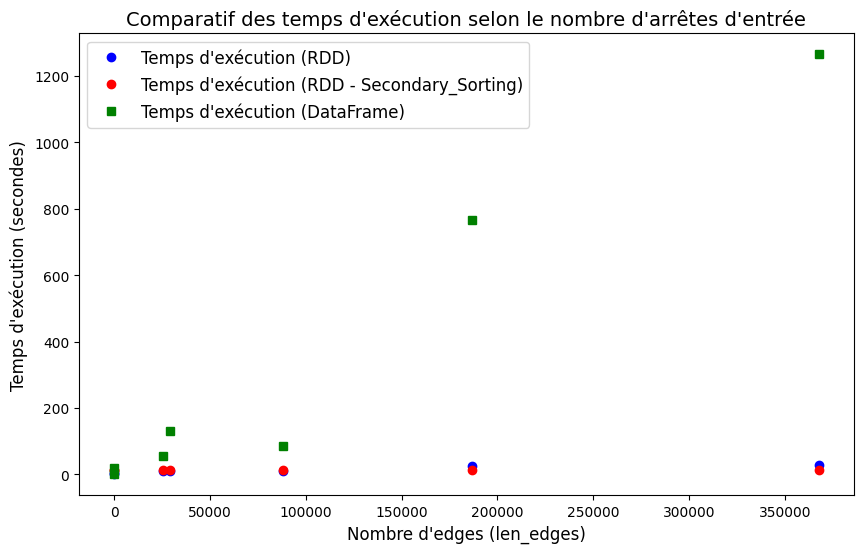

In [14]:
# URL des datasets
urls = [
    "https://snap.stanford.edu/data/email-Eu-core.txt.gz",
    "https://snap.stanford.edu/data/email-Enron.txt.gz",
    "https://snap.stanford.edu/data/facebook_combined.txt.gz",
    "https://snap.stanford.edu/data/ca-GrQc.txt.gz",
    "https://snap.stanford.edu/data/ca-CondMat.txt.gz",
    "https://snap.stanford.edu/data/cit-HepPh.txt.gz"]

urls_description = process_urls_to_dicts(urls)
# Ajout du graphe vide (en vue de l'estimation des coefficients directeurs)
urls_description.append({"url": "Vide", "edges": empty_eges, "len_edges": len(empty_eges)})
# Ajout du graphe de l'exemple
urls_description.append({"url": "Exemple", "edges": edges_article, "len_edges": len(edges_article)})
urls_description.sort(key=lambda x: x.get('len_edges', 0))

results = []

check_integrity = True

for url_description in urls_description[:-1]:
    print("SparkSession opening.")
    spark_session = SparkSession \
        .builder \
        .appName("PySpark Hardcoded Graph") \
        .getOrCreate()
    edges = url_description.get("edges")
    numSlices = None
    debug = False
    # Create GraphRDD, RDD_Demo_Secondary_Sorting and GraphDF instances
    RDD = GraphRDD(spark_session, edges, numSlices=numSlices)
    RDD_Secondary_Sorting = GraphRDD_Secondary_Sorting(spark_session, edges, numSlices=numSlices)
    DF = GraphDF(spark_session, edges, numSlices=numSlices)
    # Execute CCF algorithm on RDD instance
    RDD.workflow()
    print("RDD done")
    # Execute CCF algorithm on RDD_Demo_Secondary_Sorting instance
    RDD_Secondary_Sorting.workflow()
    # Execute CCF algorithm on DF instance
    DF.workflow()
    # Mise à jour de la liste des résultats
    results.append({
        "url": url_description.get("url"),
        "len_edges": url_description.get("len_edges"),
        "exectime_RDD": RDD.ccf_metrics["exec_time"],
        "exectime_RDD_Demo_Secondary_Sorting": RDD_Demo_Secondary_Sorting.ccf_metrics["exec_time"],
        "exectime_Dataframe": DF.ccf_metrics["exec_time"]
    })
    # spark_session.stop() peut poser des problèmes dans databricks
    spark_session.stop()
    print("SparkSession closed.")
    if check_integrity:
        assert RDD_Demo.ccf_metrics.get("nb_iterations") == RDD_Demo_Secondary_Sorting.ccf_metrics.get("nb_iterations")
        assert RDD_Demo.ccf_metrics.get("label_clusters") == RDD_Demo_Secondary_Sorting.ccf_metrics.get("label_clusters")
        assert RDD_Demo.ccf_metrics.get("clusters") == RDD_Demo_Secondary_Sorting.ccf_metrics.get("clusters")
        assert RDD_Demo.ccf_metrics.get("nb_iterations") == DF_Demo.ccf_metrics.get("nb_iterations")
        assert RDD_Demo.ccf_metrics.get("label_clusters") == DF_Demo.ccf_metrics.get("label_clusters")
        assert RDD_Demo.ccf_metrics.get("clusters") == DF_Demo.ccf_metrics.get("clusters")
        print(f"Integrity check passed with dataset {url_description.get('url')}.")

# Extraction des données pour le graphe
len_edges = [result["len_edges"] for result in results]
exectime_RDD = [result["exectime_RDD"] for result in results]
exectime_RDD_Secondary_Sorting = [result["exectime_RDD_Demo_Secondary_Sorting"] for result in results]
exectime_Dataframe = [result["exectime_Dataframe"] for result in results]

# Création du graphe
plt.figure(figsize=(10, 6))
plt.plot(len_edges, exectime_RDD, label="Temps d'exécution (RDD)", linestyle='', marker='o', color='blue')
plt.plot(len_edges, exectime_RDD_Secondary_Sorting, label="Temps d'exécution (RDD - Secondary_Sorting)", linestyle='', marker='o', color='red')
plt.plot(len_edges, exectime_Dataframe, label="Temps d'exécution (DataFrame)", linestyle='', marker='s', color='green')

# Ajouter des titres et des labels
plt.title("Comparatif des temps d'exécution selon le nombre d'arrêtes d'entrée", fontsize=14)
plt.xlabel("Nombre d'edges (len_edges)", fontsize=12)
plt.ylabel("Temps d'exécution (secondes)", fontsize=12)

# Ajouter une légende
plt.legend(fontsize=12)

# Ajouter une grille
plt.grid(True, linestyle=' ', alpha=0.7)

# Afficher le graphe
plt.show()

Coefficient directeur du temps d'exécution (RDD) : 6.916656618351054e-05 et RDD (secondary sorting) : -1.2776970755406432e-20
Coefficient directeur de exectime_Dataframe (slope) : 0.0035444150495343722
Coefficient exponentiel de exectime_Dataframe : [1.28687698e+02 6.32058651e-06]


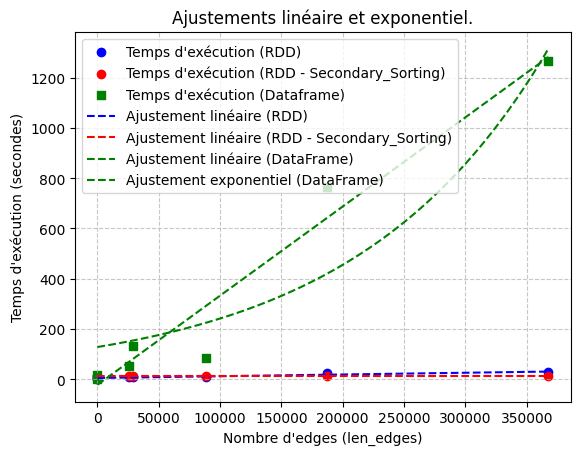

In [15]:
# Calcul du coefficient directeur (ajustement linéaire exectime_RDD et exectime_RDD_Secondary_Sorting)
coeffs_linear_RDD = np.polyfit(len_edges, exectime_RDD, 1)
coeffs_linear_RDD_Secondary_Sorting = np.polyfit(len_edges, exectime_RDD_Secondary_Sorting, 1)
slope_RDD = coeffs_linear_RDD[0]
slope_RDD_Secondary_Sorting = coeffs_linear_RDD_Secondary_Sorting[0]
print(f"Coefficient directeur du temps d'exécution (RDD) : {slope_RDD} et RDD (secondary sorting) : {slope_RDD_Secondary_Sorting}")


# Calcul du coefficient directeur (exectime_Dataframe, ajustement linéaire)
coeffs_linear_Dataframe = np.polyfit(len_edges, exectime_Dataframe, 1)
slope_Dataframe = coeffs_linear_Dataframe[0]
print(f"Coefficient directeur de exectime_Dataframe (slope) : {slope_Dataframe}")

# Définir la fonction
def exponential_func(x, a, b):
    return a * np.exp(b * x)


# Calcul du coefficient exponentiel (exectime_Dataframe, ajustement exponentiel)
# p0 est la liste pour l'estimation pour a et b comme valeurs intiales.
# En l'occurrence pour une liste vide a =
params, _ = curve_fit(exponential_func, len_edges, exectime_Dataframe, p0=[exectime_Dataframe[0], 0.00001])
exponential_coefficient = params[:]
print(f"Coefficient exponentiel de exectime_Dataframe : {exponential_coefficient}")

# Points originaux
plt.scatter(len_edges, exectime_RDD, label="Temps d'exécution (RDD)", marker='o', color='blue')
plt.scatter(len_edges, exectime_RDD_Secondary_Sorting, label="Temps d'exécution (RDD - Secondary_Sorting)", marker='o', color='red')
plt.scatter(len_edges, exectime_Dataframe, label="Temps d'exécution (Dataframe)", marker='s', color='green')

# Ajustements
x_fit = np.linspace(builtins.min(len_edges), builtins.max(len_edges), 100)
y_fit_linear_RDD = coeffs_linear_RDD[0] * x_fit + coeffs_linear_RDD[1]
y_fit_linear_RDD_Secondary_Sorting = coeffs_linear_RDD_Secondary_Sorting[0] * x_fit + coeffs_linear_RDD_Secondary_Sorting[1]
y_fit_linear_Dataframe = coeffs_linear_Dataframe[0] * x_fit + coeffs_linear_Dataframe[1]
y_fit_exponential = exponential_func(x_fit, *params)

plt.plot(x_fit, y_fit_linear_RDD, label="Ajustement linéaire (RDD)", color='blue', linestyle='--')
plt.plot(x_fit, y_fit_linear_RDD_Secondary_Sorting, label="Ajustement linéaire (RDD - Secondary_Sorting)", color='red', linestyle='--')
plt.plot(x_fit, y_fit_linear_Dataframe, label="Ajustement linéaire (DataFrame)", color='green', linestyle='--')
plt.plot(x_fit, y_fit_exponential, label="Ajustement exponentiel (DataFrame)", color='green', linestyle='--')

# Ajouter des titres et légendes
plt.title("Ajustements linéaire et exponentiel.")
plt.xlabel("Nombre d'edges (len_edges)")
plt.ylabel("Temps d'exécution (secondes)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Analyse quantitative sur les temps d'exécution entre RDD et RDD secondary sorting

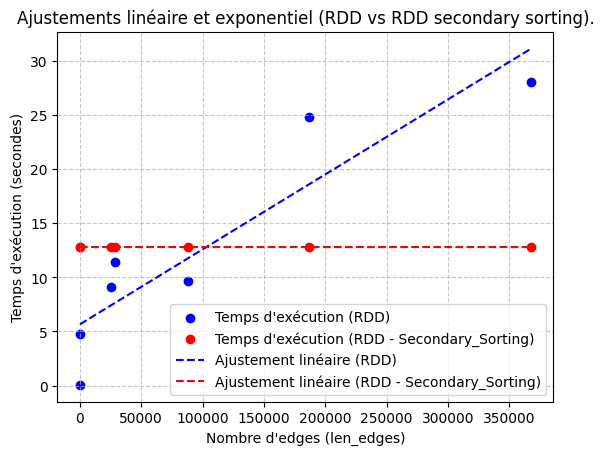

In [24]:
# Points originaux
plt.scatter(len_edges, exectime_RDD, label="Temps d'exécution (RDD)", marker='o', color='blue')
plt.scatter(len_edges, exectime_RDD_Secondary_Sorting, label="Temps d'exécution (RDD - Secondary_Sorting)", marker='o', color='red')

# Ajustements
x_fit = np.linspace(builtins.min(len_edges), builtins.max(len_edges), 100)
y_fit_linear_RDD = coeffs_linear_RDD[0] * x_fit + coeffs_linear_RDD[1]
y_fit_linear_RDD_Secondary_Sorting = coeffs_linear_RDD_Secondary_Sorting[0] * x_fit + coeffs_linear_RDD_Secondary_Sorting[1]

plt.plot(x_fit, y_fit_linear_RDD, label="Ajustement linéaire (RDD)", color='blue', linestyle='--')
plt.plot(x_fit, y_fit_linear_RDD_Secondary_Sorting, label="Ajustement linéaire (RDD - Secondary_Sorting)", color='red', linestyle='--')

# Ajouter des titres et légendes
plt.title("Ajustements linéaire et exponentiel (RDD vs RDD secondary sorting).")
plt.xlabel("Nombre d'edges (len_edges)")
plt.ylabel("Temps d'exécution (secondes)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()